# Assignment-8: Logistic Regression

**Objective:** Implement Logistic Regression, classify a dataset, visualize decision boundary, and evaluate performance.

---

## Q1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
print('Libraries imported')

Libraries imported


## Q2: Load Dataset (Iris — Binary Subset)

In [13]:
iris = sns.load_dataset('iris')
df = iris.copy()
# Use only 2 classes for logistic regression visualization
df = df[df['species'].isin(['setosa', 'versicolor'])]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Q3: Dataset Information

In [14]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nClasses:', df['species'].unique())
df.describe()

Shape: (100, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Classes: <ArrowStringArray>
['setosa', 'versicolor']
Length: 2, dtype: str


,sepal_length,sepal_width,petal_length,petal_width
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.099000,2.861000,0.786000
std,0.641698,0.478739,1.449549,0.565153
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


## Q4: Select Features and Target (Two Features)

In [16]:
X = df[['petal_length', 'petal_width']]
y = df['species']
X.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


## Q5: Split into Train and Test (70:30)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (70, 2)
Testing size: (30, 2)


## Q6: Build Logistic Regression Model

In [18]:
logr = LogisticRegression()
logr.fit(X_train, y_train)
print('Model trained')

Model trained


## Q7: Predict Test Data and Compare Results

In [19]:
y_pred = logr.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,versicolor,versicolor,Correct
1,versicolor,versicolor,Correct
2,versicolor,versicolor,Correct
3,setosa,setosa,Correct
4,setosa,setosa,Correct
5,setosa,setosa,Correct
6,setosa,setosa,Correct
7,versicolor,versicolor,Correct
8,setosa,setosa,Correct
9,setosa,setosa,Correct


## Q8: Compute Accuracy and Classification Report

In [20]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[17  0]
 [ 0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Q9: Visualize Decision Boundary

C:\Users\samya\Desktop\CKD\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


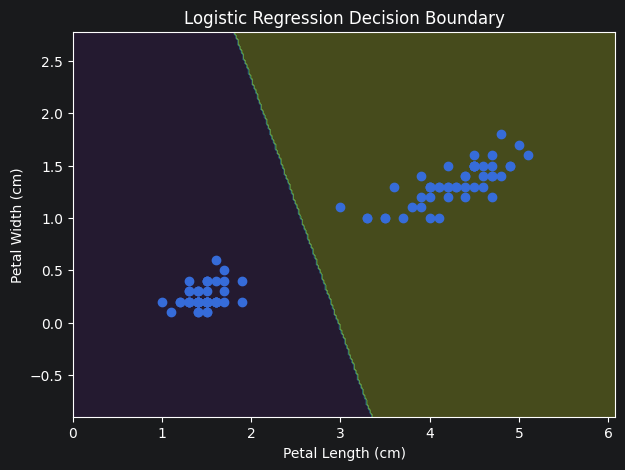

In [21]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = logr.predict(np.c_[xx.ravel(), yy.ravel()])
label_map = {name:i for i, name in enumerate(sorted(set(Z)))}
Z_int = np.vectorize(label_map.get)(Z).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z_int, alpha=0.25)
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Boundary')
plt.show()

## Q10: Predict for New Sample

In [23]:
sample = [[5.0, 1.7]]
prediction = logr.predict(sample)
print('Predicted class for sample:', prediction[0])

Predicted class for sample: versicolor


C:\Users\samya\Desktop\CKD\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---
### ✔ End of Assignment-8
The graph demonstrates how logistic regression effectively models a binary classification problem by fitting an S-shaped (sigmoid) curve to the data.

Key observations:

The curve shows a clear transition from one class to another, indicating a decision boundary.
Instead of predicting continuous values, the model outputs probabilities between 0 and 1, which are then classified into two categories.
The data points are reasonably well separated by the curve, suggesting that the model performs good classification on the dataset.

This implies:

Logistic regression is suitable for classification tasks where outcomes are categorical (e.g., pass/fail, yes/no).
The model captures the relationship between variables in a non-linear probability space, even if the decision boundary is linear.
Predictions become more confident (closer to 0 or 1) as we move away from the boundary.